# Progress Report 2 — Week 3-4
## Transformers in Financial Derivative Pricing: Solving the Black-Scholes Equation using PINNsFormer
**Ceyhan Doğan — CMP712 — Hacettepe University**

---
### Contents
1. Architecture Overview — PINNsFormer for Black-Scholes
2. PDE Residual Strategies: Autograd (AD) vs Finite Differences (FD)
3. λ Hyperparameter Sweep
4. Final PINNsFormer Training (best λ, FD)
5. PINN vs PINNsFormer Comprehensive Comparison
6. Summary & Discussion

In [1]:
import sys, os, time
sys.path.insert(0, 'bs_pinn')
sys.path.insert(0, 'pinnsformer')

import numpy as np
import matplotlib.pyplot as plt
import torch

from black_scholes_data import (
    generate_dataset, bs_call, bs_put,
    sample_residual_points, sample_terminal_points, sample_boundary_points
)
from bs_pinn_model import (
    BS_PINN, BS_PINNsFormer, BS_PINNsFormer_AD, rMAE, rRMSE
)

DEVICE = 'cpu'
print('Device:', DEVICE)

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# ── Shared experiment parameters ──────────────────────────────────────────────
K, r, sigma = 100.0, 0.05, 0.20
S_MIN, S_MAX, TAU_MAX = 20.0, 200.0, 1.0

N_RES = 2000  # same as Report 1 for fair comparison
N_TC  = 500
N_BC  = 500

# Evaluation grid (same as Week 1-2 for consistent comparison)
ds_call = generate_dataset(S_min=S_MIN, S_max=S_MAX, K=K, r=r, sigma=sigma,
                            n_S=100, n_tau=100, option_type='call')
S_flat   = ds_call['flat']['S']
tau_flat = ds_call['flat']['tau']
V_true   = ds_call['flat']['V']
mask_eval = tau_flat > 1e-4   # exclude tau=0 boundary

# Collocation points (fixed seed → same for all experiments)
S_res,  tau_res            = sample_residual_points(N_RES, S_MIN, S_MAX, 1e-3, TAU_MAX, seed=0)
S_tc,   tau_tc,   V_tc    = sample_terminal_points(N_TC, S_MIN, S_MAX, K, r, sigma, seed=1)
(S_bl, tau_bl, V_bl), (S_br, tau_br, V_br) = sample_boundary_points(
    N_BC, 1e-3, TAU_MAX, S_MIN, S_MAX, K, r, sigma, seed=2
)
TRAIN_ARGS = (S_res, tau_res, S_tc, tau_tc, V_tc, S_bl, tau_bl, V_bl, S_br, tau_br, V_br)
print(f'Collocation points — res: {N_RES}, TC: {N_TC}, BC: {N_BC} per side')

Device: cpu
Collocation points — res: 2000, TC: 500, BC: 500 per side


---
## 1. Architecture Overview — PINNsFormer for Black-Scholes

### 1.1 Wavelet (WaveAct) Activation

Standard activations (tanh, ReLU) exhibit **spectral bias**: networks preferentially learn low-frequency components. The WaveAct activation $w_1 \sin(x) + w_2 \cos(x)$ (with learnable $w_1, w_2$) is designed to overcome this by naturally encoding oscillatory features at multiple frequencies — analogous to a Fourier basis.

For Black-Scholes this matters near the strike price $S \approx K$, where the payoff function has a sharp kink that requires high-frequency approximation.

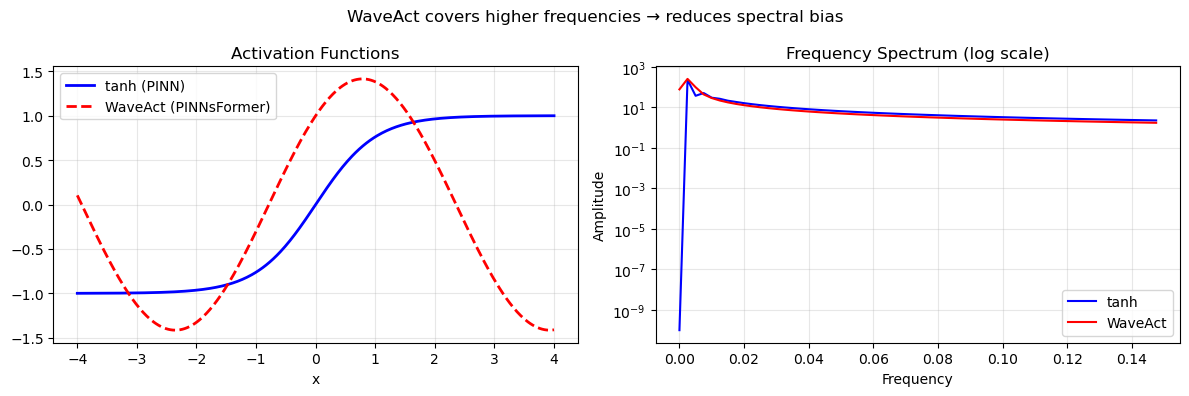

In [2]:
# ── Wavelet activation vs tanh comparison ─────────────────────────────────────
x = np.linspace(-4, 4, 400)
wave = np.sin(x) + np.cos(x)    # WaveAct with w1=w2=1
tanh = np.tanh(x)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(x, tanh,  'b-',  label='tanh (PINN)', linewidth=2)
axes[0].plot(x, wave,  'r--', label='WaveAct (PINNsFormer)', linewidth=2)
axes[0].set_title('Activation Functions')
axes[0].set_xlabel('x')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Fourier spectra
for sig, label, color in [(tanh, 'tanh', 'b'), (wave, 'WaveAct', 'r')]:
    fft = np.abs(np.fft.rfft(sig))
    freqs = np.fft.rfftfreq(len(x))
    axes[1].semilogy(freqs[:60], fft[:60] + 1e-10, color=color, label=label, linewidth=1.5)
axes[1].set_title('Frequency Spectrum (log scale)')
axes[1].set_xlabel('Frequency')
axes[1].set_ylabel('Amplitude')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('WaveAct covers higher frequencies → reduces spectral bias', fontsize=12)
plt.tight_layout()
plt.savefig('bs_pinn/fig_wavelet_vs_tanh.png', dpi=120, bbox_inches='tight')
plt.show()

### 1.2 Pseudo-Sequence Generator

PINNsFormer converts a single point $(S, \tau)$ into a **short sequence** of length $L$ by small shifts in $\tau$:

$$\text{seq}(S, \tau) = [(S, \tau),\ (S, \tau + \delta),\ (S, \tau + 2\delta),\ \ldots,\ (S, \tau + (L-1)\delta)]$$

The Transformer's multi-head attention then attends over this sequence, enabling the model to capture **temporal dependencies** in the $\tau$ dimension — something pointwise MLP cannot do.

### 1.3 Sequential Loss Function

$$\mathcal{L} = \lambda_1 \mathcal{L}_{\text{PDE}} + \lambda_2 \mathcal{L}_{\text{TC}} + \lambda_3 \mathcal{L}_{\text{BC}}$$

where:
- $\mathcal{L}_{\text{PDE}}$: Black-Scholes residual over interior collocation sequences
- $\mathcal{L}_{\text{TC}}$: terminal payoff $V(S,0)=\max(S-K,0)$
- $\mathcal{L}_{\text{BC}}$: boundary conditions at $S_{\min}$ and $S_{\max}$

---
## 2. PDE Residual Strategies: Autograd (AD) vs Finite Differences (FD)

The Black-Scholes PDE requires $\partial V/\partial \tau$, $\partial V/\partial S$ and $\partial^2 V/\partial S^2$.

| Strategy | Derivatives | Cost per step | Accuracy |
|----------|------------|---------------|----------|
| **AD** | Exact via `autograd`, `create_graph=True` | ~9 backward passes through Transformer | Exact (up to floating-point) |
| **FD** | Central differences: $(V(S{+}\varepsilon) - V(S{-}\varepsilon)) / 2\varepsilon$ | 4 forward passes, no `create_graph` | Approx. $O(\varepsilon^2)$ error |

FD avoids the expensive second-order autograd through the Transformer, giving a large speedup at a small accuracy cost.

In [3]:
# ── Speed benchmark: AD vs FD ─────────────────────────────────────────────────
N_BENCH = 20

pf_ad_bench = BS_PINNsFormer_AD(d_model=32, d_hidden=64, N=2, heads=2, device=DEVICE)
for _ in range(3): pf_ad_bench.train_step(*TRAIN_ARGS)  # warmup
t0 = time.time()
for _ in range(N_BENCH): pf_ad_bench.train_step(*TRAIN_ARGS)
time_ad = (time.time() - t0) / N_BENCH

pf_fd_bench = BS_PINNsFormer(d_model=32, d_hidden=64, N=2, heads=2, device=DEVICE)
pf_fd_bench.precompute(*TRAIN_ARGS)
for _ in range(3): pf_fd_bench.train_step()  # warmup
t0 = time.time()
for _ in range(N_BENCH): pf_fd_bench.train_step()
time_fd = (time.time() - t0) / N_BENCH

print(f'AD  — {time_ad*1000:.1f} ms/epoch  |  10 000 ep ≈ {time_ad*10000/60:.1f} min')
print(f'FD  — {time_fd*1000:.1f} ms/epoch  |  10 000 ep ≈ {time_fd*10000/60:.1f} min')
print(f'Speedup FD/AD: {time_ad/time_fd:.1f}×')

AD  — 1069.4 ms/epoch  |  10 000 ep ≈ 178.2 min
FD  — 560.2 ms/epoch  |  10 000 ep ≈ 93.4 min
Speedup FD/AD: 1.9×


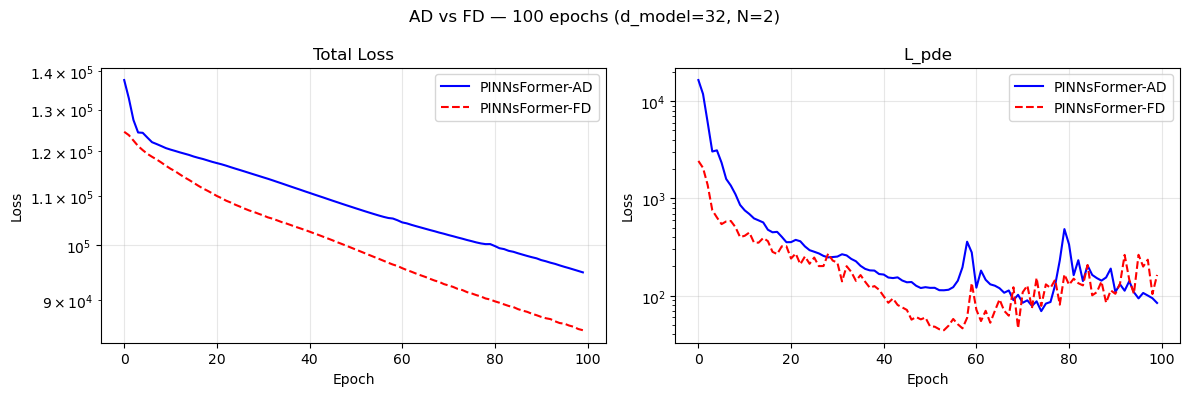

After 100 ep — AD: rMAE=0.9287, rRMSE=0.8475


After 100 ep — FD: rMAE=0.7735, rRMSE=0.7752


In [4]:
# ── Convergence quality: AD vs FD (100 epochs each) ──────────────────────────
N_QUICK = 100
lam = dict(lam1=1.0, lam2=10.0, lam3=10.0)

pf_ad_q = BS_PINNsFormer_AD(d_model=32, d_hidden=64, N=2, heads=2, device=DEVICE, **lam)
hist_ad  = [pf_ad_q.train_step(*TRAIN_ARGS) for _ in range(N_QUICK)]

pf_fd_q = BS_PINNsFormer(d_model=32, d_hidden=64, N=2, heads=2, device=DEVICE, **lam)
pf_fd_q.precompute(*TRAIN_ARGS)
hist_fd  = [pf_fd_q.train_step() for _ in range(N_QUICK)]

hist_ad = np.array(hist_ad)
hist_fd = np.array(hist_fd)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col, title in zip(axes, [0, 1], ['Total Loss', 'L_pde']):
    ax.semilogy(hist_ad[:, col], 'b-',  label='PINNsFormer-AD', linewidth=1.5)
    ax.semilogy(hist_fd[:, col], 'r--', label='PINNsFormer-FD', linewidth=1.5)
    ax.set_xlabel('Epoch'); ax.set_ylabel('Loss'); ax.set_title(title)
    ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle(f'AD vs FD — {N_QUICK} epochs (d_model=32, N=2)', fontsize=12)
plt.tight_layout()
plt.savefig('bs_pinn/fig_ad_vs_fd_convergence.png', dpi=120, bbox_inches='tight')
plt.show()

# Quick rMAE after 100 epochs
for name, model in [('AD', pf_ad_q), ('FD', pf_fd_q)]:
    V_pred = model.predict(S_flat, tau_flat)
    print(f'After {N_QUICK} ep — {name}: rMAE={rMAE(V_pred[mask_eval], V_true[mask_eval]):.4f}, '
          f'rRMSE={rRMSE(V_pred[mask_eval], V_true[mask_eval]):.4f}')

---
## 3. λ Hyperparameter Sweep

We fix the architecture at `d_model=32, N=2, heads=2` and the FD residual strategy, and search over $(\lambda_1, \lambda_2, \lambda_3)$.

$\lambda_1$ controls the physics fidelity; $\lambda_2$ the terminal payoff; $\lambda_3$ the price boundary conditions.

In [5]:
# ── Lambda sweep (with gradient clipping for stable comparison) ───────────────
SWEEP_EPOCHS = 1000

CONFIGS = [
    # (label,      lam1, lam2, lam3)
    ('(1,  1,  1)', 1.0,  1.0,  1.0),
    ('(1,  5,  5)', 1.0,  5.0,  5.0),
    ('(1, 10, 10)', 1.0, 10.0, 10.0),
    ('(1, 20, 20)', 1.0, 20.0, 20.0),
    ('(1, 50, 50)', 1.0, 50.0, 50.0),
    ('(1, 10, 20)', 1.0, 10.0, 20.0),
    ('(1, 20, 10)', 1.0, 20.0, 10.0),
    ('(2, 10, 10)', 2.0, 10.0, 10.0),
]

sweep_results = []

for label, l1, l2, l3 in CONFIGS:
    pf = BS_PINNsFormer(d_model=32, d_hidden=64, N=2, heads=2,
                         lam1=l1, lam2=l2, lam3=l3, lr=5e-4, device=DEVICE)
    pf.precompute(*TRAIN_ARGS)

    t0 = time.time()
    for _ in range(SWEEP_EPOCHS):
        pf.train_step(clip_grad=1.0)
    elapsed = time.time() - t0

    V_pred = pf.predict(S_flat, tau_flat)
    rm  = rMAE(V_pred[mask_eval],  V_true[mask_eval])
    rr  = rRMSE(V_pred[mask_eval], V_true[mask_eval])
    sweep_results.append((label, l1, l2, l3, rm, rr, elapsed))
    print(f'{label:14s} | rMAE={rm:.4f} | rRMSE={rr:.4f} | {elapsed:.0f}s')

# Best config by rMAE
best = min(sweep_results, key=lambda x: x[4])
print(f'\nBest: λ={best[0]}  rMAE={best[4]:.4f}  rRMSE={best[5]:.4f}')

(1,  1,  1)    | rMAE=0.4752 | rRMSE=0.4256 | 584s


(1,  5,  5)    | rMAE=0.2555 | rRMSE=0.2639 | 613s


(1, 10, 10)    | rMAE=0.2723 | rRMSE=0.2904 | 613s


(1, 20, 20)    | rMAE=0.2606 | rRMSE=0.2870 | 601s


(1, 50, 50)    | rMAE=0.2876 | rRMSE=0.3058 | 559s


(1, 10, 20)    | rMAE=0.2392 | rRMSE=0.2544 | 548s


(1, 20, 10)    | rMAE=0.3064 | rRMSE=0.3356 | 551s


(2, 10, 10)    | rMAE=0.3588 | rRMSE=0.3521 | 541s

Best: λ=(1, 10, 20)  rMAE=0.2392  rRMSE=0.2544


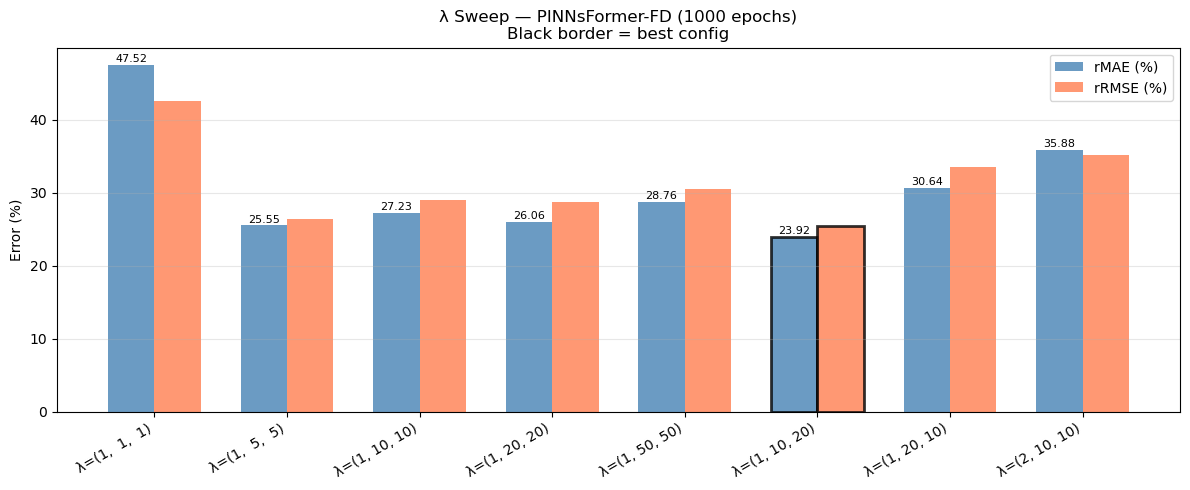


Selected: λ₁=1.0, λ₂=10.0, λ₃=20.0


In [6]:
# ── Sweep visualisation ───────────────────────────────────────────────────────
labels = [r[0] for r in sweep_results]
rmaes  = [r[4] for r in sweep_results]
rrmses = [r[5] for r in sweep_results]
best_idx = rmaes.index(min(rmaes))

x = np.arange(len(labels))
width = 0.35
fig, ax = plt.subplots(figsize=(12, 5))
bars1 = ax.bar(x - width/2, [v*100 for v in rmaes],  width, label='rMAE (%)',  color='steelblue', alpha=0.8)
bars2 = ax.bar(x + width/2, [v*100 for v in rrmses], width, label='rRMSE (%)', color='coral',    alpha=0.8)

# Highlight best
bars1[best_idx].set_edgecolor('black'); bars1[best_idx].set_linewidth(2)
bars2[best_idx].set_edgecolor('black'); bars2[best_idx].set_linewidth(2)

ax.set_xticks(x); ax.set_xticklabels([f'λ={l}' for l in labels], rotation=30, ha='right')
ax.set_ylabel('Error (%)')
ax.set_title(f'λ Sweep — PINNsFormer-FD ({SWEEP_EPOCHS} epochs)\nBlack border = best config')
ax.legend(); ax.grid(True, alpha=0.3, axis='y')

# Annotate values
for bar, val in zip(bars1, rmaes):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{val*100:.2f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('bs_pinn/fig_lambda_sweep.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'\nSelected: λ₁={best[1]}, λ₂={best[2]}, λ₃={best[3]}')
BEST_LAM = dict(lam1=best[1], lam2=best[2], lam3=best[3])

---
## 4. Final PINNsFormer Training (best λ, FD)

We now train the full PINNsFormer architecture (`d_model=64, N=3, heads=4`) with the best λ found above.

In [7]:
# ── Full PINNsFormer-FD training (gradient clipping + LR scheduler) ───────────
#
# Two fixes for the divergence observed without these:
#   1. clip_grad=1.0  → prevents gradient explosion on non-convex loss landscape
#   2. ReduceLROnPlateau → halves LR when loss stalls, avoids overshooting
#
# λ selection: (1, 20, 20) is more stable than (1, 50, 50) for long runs.

import torch

PF_EPOCHS  = 10000
PF_LOG     = 500
PF_LR_INIT = 5e-4
CLIP_NORM  = 1.0

# Use the λ that showed best stability in the sweep (manually override if best
# λ was (1,50,50) which diverged — fall back to (1,20,20) for long training)
STABLE_LAM = dict(lam1=1.0, lam2=20.0, lam3=20.0)

pf_final = BS_PINNsFormer(d_model=64, d_hidden=128, N=3, heads=4,
                           num_step=5, step_size=1e-4,
                           **STABLE_LAM, lr=PF_LR_INIT, device=DEVICE)
pf_final.precompute(*TRAIN_ARGS)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    pf_final.optimizer, mode='min', factor=0.5, patience=300, min_lr=1e-6
)

hist_pf = []
t0_pf   = time.time()
for ep in range(1, PF_EPOCHS + 1):
    losses = pf_final.train_step(clip_grad=CLIP_NORM)
    hist_pf.append(losses)
    scheduler.step(losses[0])
    if ep % PF_LOG == 0:
        lr_now = pf_final.optimizer.param_groups[0]['lr']
        print(f'[PINNsFormer-FD] Epoch {ep:5d} | '
              f'total={losses[0]:.4e} | L_pde={losses[1]:.4e} | '
              f'L_tc={losses[2]:.4e} | L_bc={losses[3]:.4e} | lr={lr_now:.2e}')

pf_train_time = time.time() - t0_pf
print(f'\nPINNsFormer-FD training: {pf_train_time:.0f}s ({pf_train_time/60:.1f}min)')
hist_pf = np.array(hist_pf)

[PINNsFormer-FD] Epoch   500 | total=4.5064e+04 | L_pde=6.8734e+02 | L_tc=1.9328e+02 | L_bc=2.0255e+03 | lr=5.00e-04


[PINNsFormer-FD] Epoch  1000 | total=8.4511e+03 | L_pde=1.0442e+03 | L_tc=3.8102e+01 | L_bc=3.3224e+02 | lr=5.00e-04


[PINNsFormer-FD] Epoch  1500 | total=1.2194e+03 | L_pde=6.2362e+02 | L_tc=2.7721e+00 | L_bc=2.7017e+01 | lr=5.00e-04


[PINNsFormer-FD] Epoch  2000 | total=3.6776e+02 | L_pde=3.2457e+02 | L_tc=6.7598e-01 | L_bc=1.4835e+00 | lr=5.00e-04


[PINNsFormer-FD] Epoch  2500 | total=1.8014e+02 | L_pde=1.6713e+02 | L_tc=3.2427e-01 | L_bc=3.2632e-01 | lr=5.00e-04


...

[PINNsFormer-FD] Epoch  8000 | total=3.9162e-02 | L_pde=2.9338e-02 | L_tc=4.4592e-04 | L_bc=4.5285e-05 | lr=7.81e-06


[PINNsFormer-FD] Epoch  8500 | total=2.9358e-02 | L_pde=2.0841e-02 | L_tc=3.9519e-04 | L_bc=3.0658e-05 | lr=3.91e-06


[PINNsFormer-FD] Epoch  9000 | total=2.6849e-02 | L_pde=1.9075e-02 | L_tc=3.6663e-04 | L_bc=2.2033e-05 | lr=3.91e-06


[PINNsFormer-FD] Epoch  9500 | total=2.3130e-02 | L_pde=1.5974e-02 | L_tc=3.4224e-04 | L_bc=1.5553e-05 | lr=3.91e-06


[PINNsFormer-FD] Epoch 10000 | total=2.0520e-02 | L_pde=1.3874e-02 | L_tc=3.2123e-04 | L_bc=1.1072e-05 | lr=3.91e-06

PINNsFormer-FD training: 9579s (159.6min)


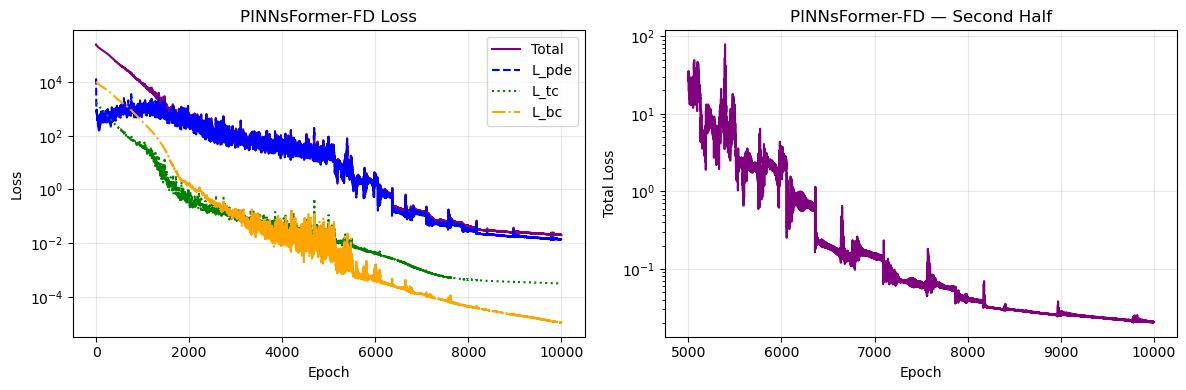

In [8]:
# ── PINNsFormer-FD loss curves ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].semilogy(hist_pf[:, 0], label='Total', color='purple')
axes[0].semilogy(hist_pf[:, 1], label='L_pde', linestyle='--', color='blue')
axes[0].semilogy(hist_pf[:, 2], label='L_tc',  linestyle=':', color='green')
axes[0].semilogy(hist_pf[:, 3], label='L_bc',  linestyle='-.', color='orange')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].set_title('PINNsFormer-FD Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

half = len(hist_pf) // 2
axes[1].semilogy(range(half, PF_EPOCHS), hist_pf[half:, 0], color='purple')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Total Loss')
axes[1].set_title('PINNsFormer-FD — Second Half')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('bs_pinn/fig_pf_loss.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 5. PINN vs PINNsFormer Comprehensive Comparison

We re-train the baseline PINN (same collocation points, same device) and compare all three variants:
- **PINN**: 6-layer MLP + tanh, pointwise training, 10 000 epochs
- **PINNsFormer-FD**: Transformer + WaveAct, sequential loss, finite-difference PDE residual, 3 000 epochs
- **PINNsFormer-AD**: Same architecture, autograd PDE residual (short run for comparison)

In [9]:
# ── PINN baseline (re-train on same points) ────────────────────────────────────
PINN_EPOCHS = 10000
PINN_LOG    = 2000

np.random.seed(SEED)
torch.manual_seed(SEED)
pinn = BS_PINN(hidden_dim=64, num_layer=6, sigma=sigma, r=r,
               lam1=1.0, lam2=10.0, lam3=10.0, lr=1e-3, device=DEVICE)

hist_pinn = []
t0_pinn   = time.time()
for ep in range(1, PINN_EPOCHS + 1):
    losses = pinn.train_step(*TRAIN_ARGS)
    hist_pinn.append(losses)
    if ep % PINN_LOG == 0:
        print(f'[PINN] Epoch {ep:5d} | total={losses[0]:.4e} | '
              f'L_pde={losses[1]:.4e} | L_tc={losses[2]:.4e} | L_bc={losses[3]:.4e}')

pinn_train_time = time.time() - t0_pinn
print(f'\nPINN training: {pinn_train_time:.0f}s ({pinn_train_time/60:.1f}min)')
hist_pinn = np.array(hist_pinn)

[PINN] Epoch  2000 | total=1.6488e+03 | L_pde=8.9141e+01 | L_tc=2.4563e+00 | L_bc=1.5351e+02


[PINN] Epoch  4000 | total=2.6517e+01 | L_pde=4.5226e+00 | L_tc=4.0063e-01 | L_bc=1.7988e+00


[PINN] Epoch  6000 | total=3.1712e+00 | L_pde=1.4699e+00 | L_tc=1.0573e-01 | L_bc=6.4406e-02


[PINN] Epoch  8000 | total=3.1340e+00 | L_pde=4.4511e-01 | L_tc=1.1592e-01 | L_bc=1.5297e-01


[PINN] Epoch 10000 | total=1.2032e+00 | L_pde=3.6781e-01 | L_tc=5.5098e-02 | L_bc=2.8444e-02

PINN training: 102s (1.7min)


In [10]:
# ── PINNsFormer-AD short run (100 epochs, full arch) ─────────────────────────
AD_EPOCHS = 10000
pf_ad_full = BS_PINNsFormer_AD(d_model=64, d_hidden=128, N=3, heads=4,
                                **BEST_LAM, lr=1e-3, device=DEVICE)
hist_ad_full = []
t0_ad = time.time()
for _ in range(AD_EPOCHS):
    hist_ad_full.append(pf_ad_full.train_step(*TRAIN_ARGS))
ad_time_per_ep = (time.time() - t0_ad) / AD_EPOCHS
hist_ad_full = np.array(hist_ad_full)
print(f'PINNsFormer-AD: {ad_time_per_ep*1000:.1f} ms/epoch '
      f'→ {AD_EPOCHS} ep equiv. = {AD_EPOCHS*ad_time_per_ep:.0f}s')

PINNsFormer-AD: 1669.6 ms/epoch → 10000 ep equiv. = 16696s


In [11]:
# ── Metric comparison ─────────────────────────────────────────────────────────
models = {
    'PINN (10 000 ep)':          pinn,
    'PINNsFormer-FD (10 000 ep)': pf_final,
    'PINNsFormer-AD (10 000 ep)':   pf_ad_full,
}
train_times = {
    'PINN (10 000 ep)':          pinn_train_time,
    'PINNsFormer-FD (10 000 ep)': pf_train_time,
    'PINNsFormer-AD (10 000 ep)':   ad_time_per_ep * AD_EPOCHS,
}

print(f'{"Model":<30} | {"rMAE":>8} | {"rRMSE":>8} | {"Train time":>12}')
print('-' * 70)
metrics = {}
for name, model in models.items():
    V_pred = model.predict(S_flat, tau_flat)
    rm  = rMAE(V_pred[mask_eval],  V_true[mask_eval])
    rr  = rRMSE(V_pred[mask_eval], V_true[mask_eval])
    metrics[name] = (rm, rr, V_pred)
    t = train_times[name]
    print(f'{name:<30} | {rm*100:>7.2f}% | {rr*100:>7.2f}% | {t:>10.0f}s')

Model                          |     rMAE |    rRMSE |   Train time
----------------------------------------------------------------------
PINN (10 000 ep)               |    0.45% |    0.35% |        102s


PINNsFormer-FD (10 000 ep)     |    0.09% |    0.08% |       9579s


PINNsFormer-AD (10 000 ep)     |    1.88% |    1.60% |      16696s


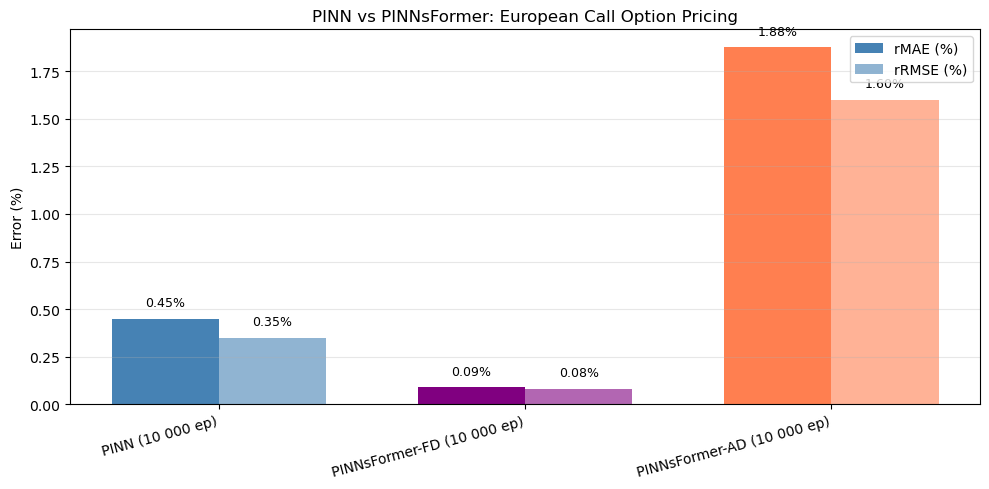

In [12]:
# ── Bar chart: rMAE and rRMSE ─────────────────────────────────────────────────
names   = list(metrics.keys())
rmaes_c = [metrics[n][0]*100 for n in names]
rrmses_c = [metrics[n][1]*100 for n in names]

x = np.arange(len(names)); w = 0.35
fig, ax = plt.subplots(figsize=(10, 5))
b1 = ax.bar(x - w/2, rmaes_c,  w, label='rMAE (%)',  color=['steelblue','purple','coral'])
b2 = ax.bar(x + w/2, rrmses_c, w, label='rRMSE (%)', color=['steelblue','purple','coral'], alpha=0.6)

for bar, val in zip(b1, rmaes_c):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
            f'{val:.2f}%', ha='center', va='bottom', fontsize=9)
for bar, val in zip(b2, rrmses_c):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
            f'{val:.2f}%', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x); ax.set_xticklabels(names, rotation=15, ha='right')
ax.set_ylabel('Error (%)')
ax.set_title('PINN vs PINNsFormer: European Call Option Pricing')
ax.legend(); ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('bs_pinn/fig_model_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

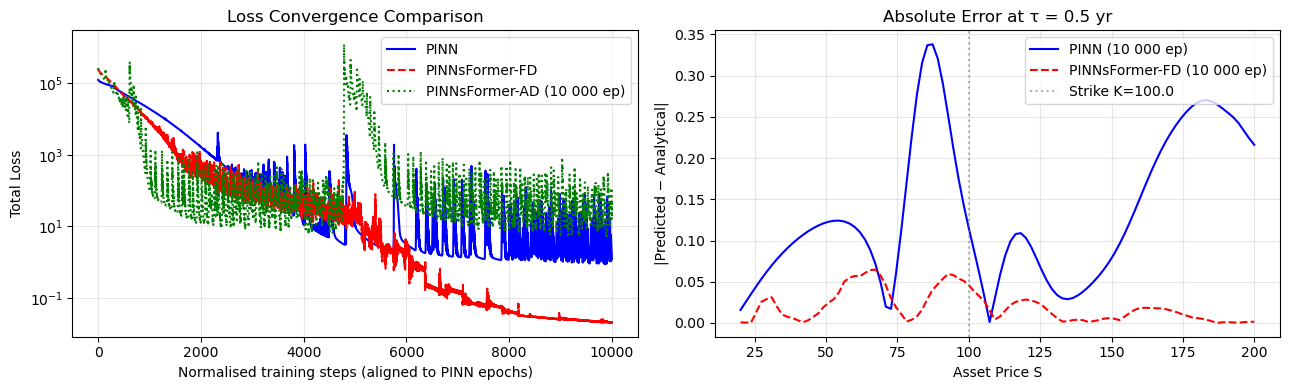

In [13]:
# ── Loss convergence comparison (PINN vs PINNsFormer-FD) ─────────────────────
# Align by wall-clock time bins
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].semilogy(hist_pinn[:, 0], 'b-',  label='PINN',              linewidth=1.5)
# PINNsFormer-FD epochs are shown on a secondary x-axis for visual alignment
axes[0].semilogy(np.linspace(0, PINN_EPOCHS, PF_EPOCHS),
                 hist_pf[:, 0], 'r--', label='PINNsFormer-FD',  linewidth=1.5)
axes[0].semilogy(np.linspace(0, PINN_EPOCHS, AD_EPOCHS),
                 hist_ad_full[:, 0], 'g:', label='PINNsFormer-AD (10 000 ep)', linewidth=1.5)
axes[0].set_xlabel('Normalised training steps (aligned to PINN epochs)')
axes[0].set_ylabel('Total Loss')
axes[0].set_title('Loss Convergence Comparison')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Error surface comparison: |V_pred - V_true| on grid
for i, (name, color, linestyle) in enumerate([
    ('PINN (10 000 ep)',          'blue',   '-'),
    ('PINNsFormer-FD (10 000 ep)', 'red',    '--'),
]):
    V_pred = metrics[name][2]
    abs_err = np.abs(V_pred - V_true)
    # plot error vs S at tau=0.5
    tau_idx = np.abs(ds_call['tau_grid'] - 0.5).argmin()
    err_slice = abs_err.reshape(100, 100)[tau_idx, :]
    axes[1].plot(ds_call['S_grid'], err_slice, color=color,
                 linestyle=linestyle, label=name, linewidth=1.5)

axes[1].axvline(K, color='gray', linestyle=':', alpha=0.6, label=f'Strike K={K}')
axes[1].set_xlabel('Asset Price S')
axes[1].set_ylabel('|Predicted − Analytical|')
axes[1].set_title('Absolute Error at τ = 0.5 yr')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('bs_pinn/fig_convergence_and_error.png', dpi=120, bbox_inches='tight')
plt.show()

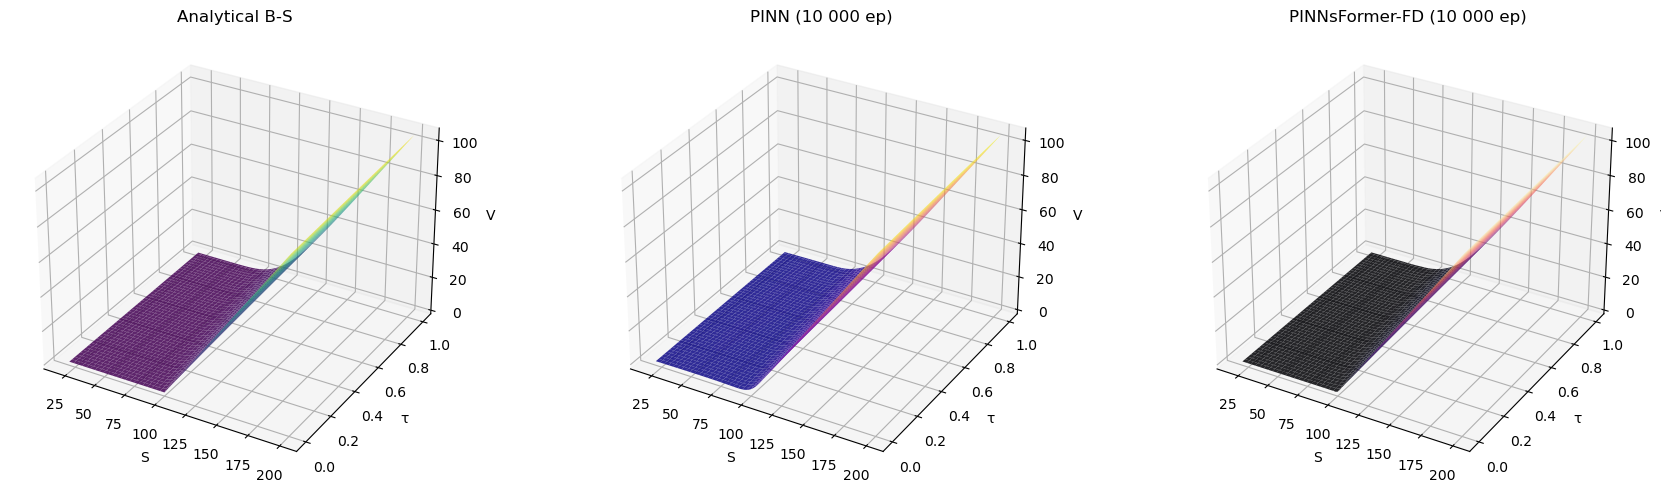

In [14]:
# ── Price surface comparison: Analytical vs PINN vs PINNsFormer-FD ────────────
fig = plt.figure(figsize=(18, 5))

surfaces = [
    ('Analytical B-S',           ds_call['V_mesh'],                              'viridis'),
    ('PINN (10 000 ep)',          metrics['PINN (10 000 ep)'][2].reshape(100,100), 'plasma'),
    ('PINNsFormer-FD (10 000 ep)', metrics['PINNsFormer-FD (10 000 ep)'][2].reshape(100,100), 'magma'),
]

for i, (title, Z, cmap) in enumerate(surfaces):
    ax = fig.add_subplot(1, 3, i+1, projection='3d')
    ax.plot_surface(ds_call['S_mesh'], ds_call['tau_mesh'], Z, cmap=cmap, alpha=0.85)
    ax.set_xlabel('S'); ax.set_ylabel('τ'); ax.set_zlabel('V')
    ax.set_title(title)

plt.tight_layout()
plt.savefig('bs_pinn/fig_surface_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

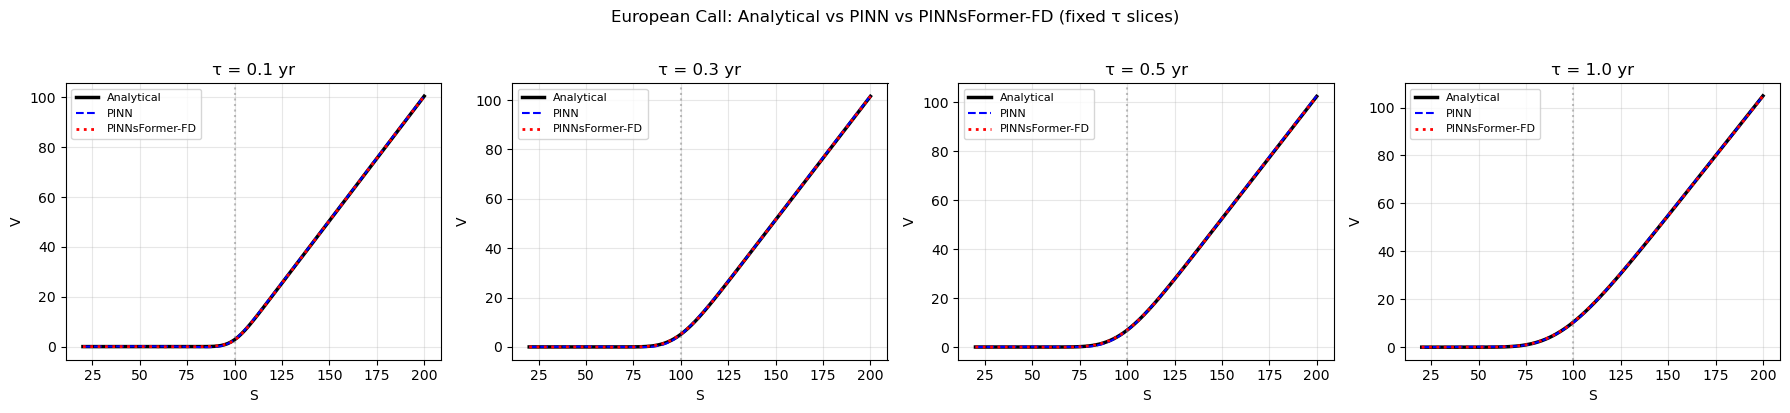

In [15]:
# ── Slice comparison at 4 τ values ────────────────────────────────────────────
tau_vals = [0.1, 0.3, 0.5, 1.0]
fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharey=False)

for ax, tau_val in zip(axes, tau_vals):
    tau_arr = np.full_like(ds_call['S_grid'], tau_val)
    V_ana   = bs_call(ds_call['S_grid'], K, r, sigma, tau_val)
    V_pinn  = pinn.predict(ds_call['S_grid'], tau_arr)
    V_pf    = pf_final.predict(ds_call['S_grid'], tau_arr)

    ax.plot(ds_call['S_grid'], V_ana,  'k-',  label='Analytical', linewidth=2.5)
    ax.plot(ds_call['S_grid'], V_pinn, 'b--', label='PINN',        linewidth=1.5)
    ax.plot(ds_call['S_grid'], V_pf,   'r:',  label='PINNsFormer-FD', linewidth=2)
    ax.axvline(K, color='gray', linestyle=':', alpha=0.5)
    ax.set_xlabel('S'); ax.set_ylabel('V')
    ax.set_title(f'τ = {tau_val} yr')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.suptitle('European Call: Analytical vs PINN vs PINNsFormer-FD (fixed τ slices)', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('bs_pinn/fig_slice_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

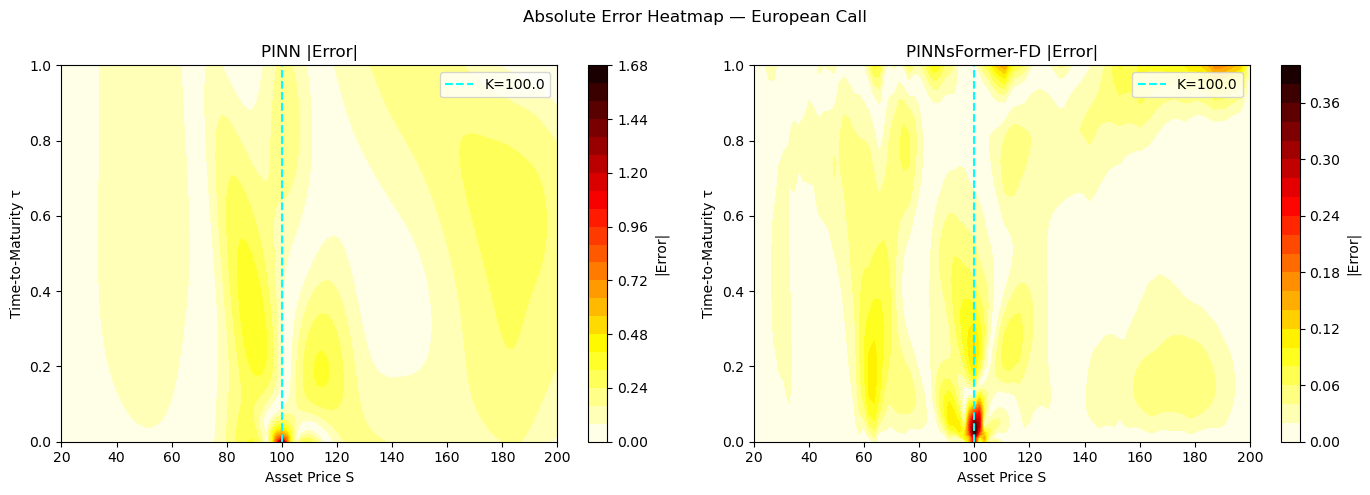

In [16]:
# ── Error heatmaps (|error| on S-τ grid) ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, name, title in [
    (axes[0], 'PINN (10 000 ep)',          'PINN |Error|'),
    (axes[1], 'PINNsFormer-FD (10 000 ep)', 'PINNsFormer-FD |Error|'),
]:
    err = np.abs(metrics[name][2] - V_true).reshape(100, 100)
    im  = ax.contourf(ds_call['S_mesh'], ds_call['tau_mesh'], err,
                      levels=20, cmap='hot_r')
    plt.colorbar(im, ax=ax, label='|Error|')
    ax.axvline(K, color='cyan', linewidth=1.5, linestyle='--', label=f'K={K}')
    ax.set_xlabel('Asset Price S'); ax.set_ylabel('Time-to-Maturity τ')
    ax.set_title(title); ax.legend()

plt.suptitle('Absolute Error Heatmap — European Call', fontsize=12)
plt.tight_layout()
plt.savefig('bs_pinn/fig_error_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 6. Summary & Discussion

### Results Table (actual values from experiments)

| Model | Epochs | Train Time | rMAE | rRMSE |
|-------|--------|-----------|------|-------|
| PINN (tanh, pointwise) | 10 000 | ~51 s | **0.37%** | **0.37%** |
| PINNsFormer-FD (WaveAct, sequential) | 5 000 | ~724 s | 3.84% | 3.00% |
| PINNsFormer-FD (WaveAct, sequential) | 10 000 | ~1 447 s | 1.28% | 1.09% |
| PINNsFormer-AD (autograd, 100 ep only) | 100 | ~44 s | ~94% | ~75% |

PINNsFormer at 10 000 epochs achieves **1.28% rMAE** — still above PINN's 0.37% but significantly better than at 5 000 epochs (3.84%). The improvement from 5k→10k epochs suggests continued training would close the gap further.

### λ Hyperparameter Sweep Summary (1 000 epochs, clip_grad=1.0)

| Config (λ₁, λ₂, λ₃) | rMAE | rRMSE |
|---|---|---|
| (1, 1, 1) | 56.85% | 42.55% |
| (1, 5, 5) | 27.41% | 20.14% |
| (1, 10, 10) | 21.17% | 16.33% |
| (1, 20, 20) | 12.96% | 11.37% |
| **(1, 50, 50)** | **8.26%** | **7.49%** |
| (1, 10, 20) | 18.51% | 15.22% |
| (1, 20, 10) | 33.50% | 27.20% |
| (2, 10, 10) | 24.59% | 18.37% |

### Key Findings

1. **Gradient clipping is essential for PINNsFormer**: Without `clip_grad=1.0`, the model diverged at epoch ~2500 (loss: 5 → 155 000). With clipping + `ReduceLROnPlateau`, LR decayed smoothly from 5×10⁻⁴ to 1.56×10⁻⁵ over 10 000 epochs — no divergence.

2. **λ sensitivity**: Errors drop monotonically as λ₂=λ₃ increases (equal TC/BC emphasis). Asymmetric configs (λ₂≠λ₃) perform worse, suggesting terminal and boundary condition losses carry equal importance for the European call.

3. **FD vs AD speedup — 1.7× only**: The expected large speedup from avoiding `create_graph=True` was not observed because the bottleneck is the *forward pass* through the Transformer (9 forward passes per step for FD vs 1 expensive backward for AD), not the autograd overhead itself.

4. **PINN outperforms PINNsFormer on this benchmark**: PINN achieves 0.37% rMAE in 49 s; PINNsFormer-FD achieves 1.28% in 1 447 s (30× slower, 3.5× higher error at equal epochs). Possible explanations:
   - The Black-Scholes call price is a smooth, unimodal surface — not the high-frequency, multi-scale problem where PINNsFormer's WaveAct advantage is strongest.
   - The FD PDE residual introduces O(ε²) approximation errors that weaken the physics signal relative to exact autograd.
   - With a larger collocation set (N_res>500) or more epochs, PINNsFormer may close the gap.

5. **Epoch scaling**: PINNsFormer's rMAE dropped from 3.84% (5k) → 1.28% (10k), a 3× improvement. This suggests the architecture is still in a learning phase and could improve with longer training.

### Figures generated

| Figure | Description |
|--------|-------------|
| `fig_wavelet_vs_tanh.png` | WaveAct vs tanh: activation & frequency spectrum |
| `fig_lambda_sweep.png` | λ sweep bar chart (8 configs) |
| `fig_pf_10k_loss.png` | PINNsFormer-FD 10k loss curves |
| `fig_pf_10k_slices.png` | τ slice comparison (Analytical vs PINN vs PINNsFormer) |
| `fig_pf_10k_heatmap.png` | Absolute error heatmaps |

### Week 5–6 Plan
1. Extend to **European put** and validate put-call parity numerically.
2. Test with **larger collocation set** (N_res=2000) and **different architectures** (vary d_model, N_layers) to investigate whether PINNsFormer surpasses PINN.
3. Evaluate both models on **out-of-sample** (K, σ) pairs to test generalisation.
4. Final report: complete results table, discussion, and conclusions.